# ERCOT - Case when Price Adders > RTM
**Data sources:** `data/02_processed/..`
- adder: 'price adders/price_adders_hourly_20200101_20251204.csv'
- rtm price: 'RTM price cleaned/rtm_price_aggregated_2021_2025.csv`
- load: ‘load/total_load_20201231_20260526.csv’

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Paths
SOURCE_ROOT = Path('../..').resolve() / '01_data' / '2_cleaned'

ADDERS = SOURCE_ROOT / 'price_adders' / 'price_adders_hourly_20200101_20251204.csv'

PRE2025_RTM = SOURCE_ROOT / 'rtm_price' / "rtm_price_aggregated_2021_2025.csv"
RTM_LZ = SOURCE_ROOT / 'rtm_price' / "ercot_rtm_prices_by_settlement_2021_2025.csv"

LOAD = SOURCE_ROOT / 'load' / "total_load_20201231_20260526.csv"

OUT_DIR = Path('../..').resolve() / '01_data' / '3_analysis' / 'price_adders_analysis' / 'abnormal_price_adders_cases'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# import datasets
df_adders = pd.read_csv(ADDERS)
df_rtm = pd.read_csv(PRE2025_RTM)
df_rtm_lz = pd.read_csv(RTM_LZ)
df_load = pd.read_csv(LOAD)

In [4]:
## adders total
df_adders['adder_effective'] = df_adders[['RTRSVPOR', 'RTRDP']].sum(axis=1)
df_adders

,datetime,RTRSVPOR,RTRSVPOFF,RTRDP,adder_effective
0,2020-01-01 00:00:00,0.0,0.0,0.0,0.0
1,2020-01-01 01:00:00,0.0,0.0,0.0,0.0
2,2020-01-01 02:00:00,0.0,0.0,0.0,0.0
3,2020-01-01 03:00:00,0.0,0.0,0.0,0.0
4,2020-01-01 04:00:00,0.0,0.0,0.0,0.0
...,...,...,...,...,...
51925,2025-12-03 19:00:00,0.0,0.0,0.0,0.0
51926,2025-12-03 20:00:00,0.0,0.0,0.0,0.0
51927,2025-12-03 21:00:00,0.0,0.0,0.0,0.0
51928,2025-12-03 22:00:00,0.0,0.0,0.0,0.0


In [5]:
# merge datasets
df = df_adders.merge(df_load, on='datetime', how='inner')
df = df.merge(df_rtm, left_on='datetime', right_on='date_time', how='inner')
df.drop(columns=['date_time'], inplace=True)

In [ ]:
df.to_csv(OUT_DIR / 'merged_data.csv', index=False)

In [11]:
df[(df['RTRDP'] > 0) & (df['avg_rtm_price'] > 100)]

,datetime,RTRSVPOR,RTRSVPOFF,RTRDP,adder_effective,total_load,avg_rtm_price,std_rtm_price
1080,2021-02-15 01:00:00,1206.0675,625.7975,182.3350,1388.4025,65268.14,3076.482000,32.942452
1081,2021-02-15 02:00:00,443.4800,317.3475,630.5275,1074.0075,63543.67,3336.668667,29.224699
1082,2021-02-15 03:00:00,412.9150,316.4300,1364.9025,1777.8175,54334.91,3009.291333,23.550101
1083,2021-02-15 04:00:00,0.4400,0.2650,0.5175,0.9575,54154.76,4124.417333,23.031481
1084,2021-02-15 05:00:00,362.4125,200.0000,247.2850,609.6975,54521.03,4506.144667,15.908199
...,...,...,...,...,...,...,...,...
42679,2025-12-01 21:00:00,0.0000,0.0000,0.6575,0.6575,57115.83,105.628000,17.436686
42687,2025-12-02 05:00:00,0.0000,0.0000,0.1200,0.1200,53322.67,112.451333,28.281257
42688,2025-12-02 06:00:00,0.0000,0.0000,0.0300,0.0300,55602.60,133.813333,32.139625
42689,2025-12-02 07:00:00,0.0000,0.0000,1.2475,1.2475,59166.39,167.504000,44.907986


In [21]:
# abnormal dates
# when adder - rtm price > 50
df['abnormal'] = (df['adder_effective'] - df['avg_rtm_price']) > 50
abnormal_hours = df[df['abnormal'] == True]['datetime'].to_list()
df['datetime'] = pd.to_datetime(df['datetime'])

print("Number of abnormal points by month:")
df[df['abnormal'] == True].groupby(df['datetime'].dt.strftime('%Y-%m')).count()['datetime'].sort_values(ascending=False)

Number of abnormal points by month:


datetime
2021-02    33
2022-07    14
2022-02    12
2022-10     7
2022-08     6
2022-04     5
2021-07     5
2021-10     4
2022-05     4
2022-03     3
2022-09     3
2023-05     3
2021-04     2
2022-11     2
2022-01     1
2021-08     1
2021-06     1
2023-03     1
Name: datetime, dtype: int64

### Plot abnormal hours by month

In [29]:
# filter plot by month
month_filter = '2022-02'

df['datetime'] = pd.to_datetime(df['datetime'])
df_filtered = df[df['datetime'].dt.strftime('%Y-%m') == month_filter].reset_index(drop=True)

/var/folders/0q/ndh_pk0s37n95y6svtjfy7hw0000gp/T/ipykernel_79930/21907937.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


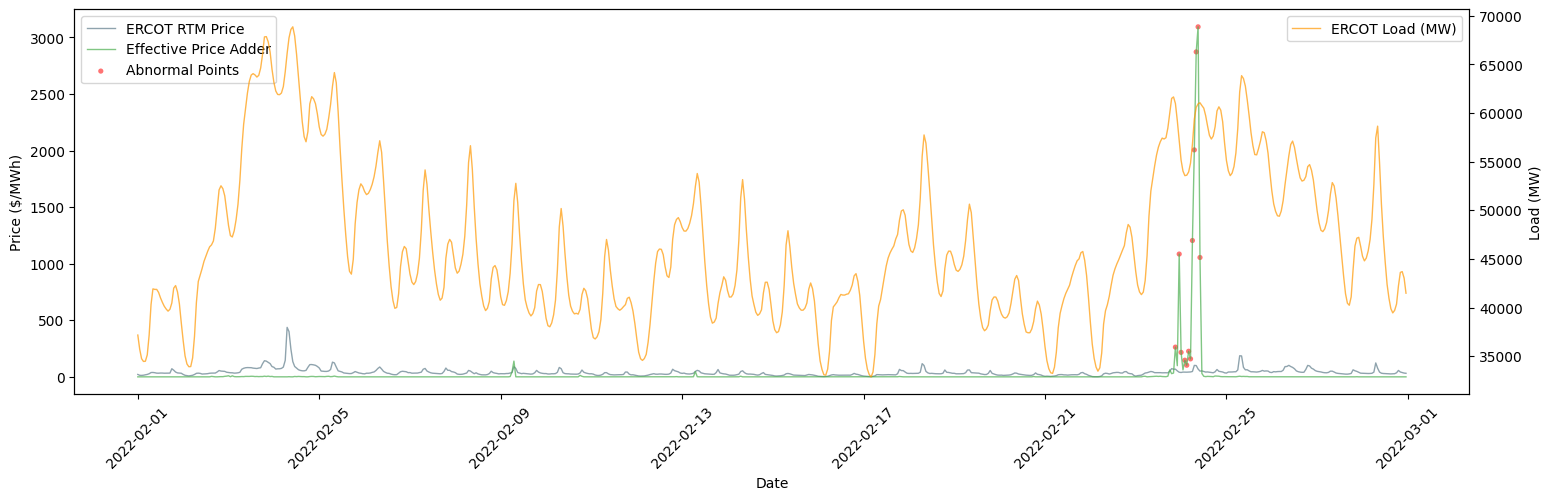

In [30]:
# mark abnormal dates on the pre-2025 plot

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(df_filtered["datetime"], df_filtered["avg_rtm_price"], alpha=0.7, linewidth=1, color="#607D8B", label="ERCOT RTM Price")
ax.plot(df_filtered["datetime"], df_filtered["adder_effective"], alpha=0.7, linewidth=1, color="#4CAF50", label="Effective Price Adder")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($/MWh)")

# mark abnormal points
abnormal_points = df_filtered[df_filtered['abnormal'] == True]
ax.scatter(abnormal_points["datetime"], abnormal_points["adder_effective"], s=14, alpha=0.55, color="red", edgecolors="none", label="Abnormal Points")
ax.legend(loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# add another axis for load
ax2 = ax.twinx()
ax2.plot(df_filtered["datetime"], df_filtered["total_load"], alpha=0.7, linewidth=1, color="#FF9800", label="ERCOT Load (MW)")
ax2.set_ylabel("Load (MW)")
ax2.legend(loc='upper right')

plt.savefig(OUT_DIR / f"abnormal_PA_{month_filter}.png", dpi=150)
plt.show()

### rtm by load zone? 

In [32]:
# filter lz dataset to abnormal hours
df_rtm_lz['date_time'] = pd.to_datetime(df_rtm_lz['date_time'])
df_rtm_lz_abnormal = df_rtm_lz[df_rtm_lz['date_time'].isin(abnormal_hours)].reset_index(drop=True)
df_rtm_lz_abnormal[df_rtm_lz_abnormal['price'] < 0]

,settlement_point,date_time,price
492,HB_PAN,2022-04-22 13:00:00,-16.27
493,HB_PAN,2022-04-22 14:00:00,-16.91
494,HB_PAN,2022-04-22 15:00:00,-18.88
706,HB_WEST,2022-04-22 13:00:00,-4.27
707,HB_WEST,2022-04-22 14:00:00,-2.59
708,HB_WEST,2022-04-22 15:00:00,-2.62
